## Simulation
Simulates asset prices with GBM

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

Parameters

In [6]:
S0    = 100    # initial price
mu    = 0.05   # annual return/drift
sigma = 0.20   # annual volatility 
T     = 7.0    # time horizon (years)
N     = int(252 * T)    # time steps (number of trading days)
I     = 20     # number of simulated paths

np.random.seed(195241)

Define simulation function

In [7]:
def gbm_simulate(S0, mu, sigma, T, N, I):  # this function is now added to utils.py for later use
    dt = 1/252 # time step length
    times = np.linspace(0, T, N+1) # array of times
    S = np.zeros((N+1, I)) # matrix to store asset values
    S[0] = S0

    for t in range (1, N+1):
        Z = np.random.standard_normal(I) # array of length I of normally distrubuted noise
        S[t] = S[t-1] * np.exp((mu - 0.5*sigma**2) * dt + sigma * np.sqrt(dt) * Z) # discretised closed form of GBM SDE
    return S, times
    

Run simulation

In [8]:
S, times = gbm_simulate(S0, mu, sigma, T, N, I)

print(f"Starting price   : ${S[0, 0]:.2f}")
print(f"Mean final price : ${S[-1].mean():.2f}")
print(f"Min  final price : ${S[-1].min():.2f}")
print(f"Max  final price : ${S[-1].max():.2f}")


Starting price   : $100.00
Mean final price : $135.95
Min  final price : $49.46
Max  final price : $227.02


Plot paths

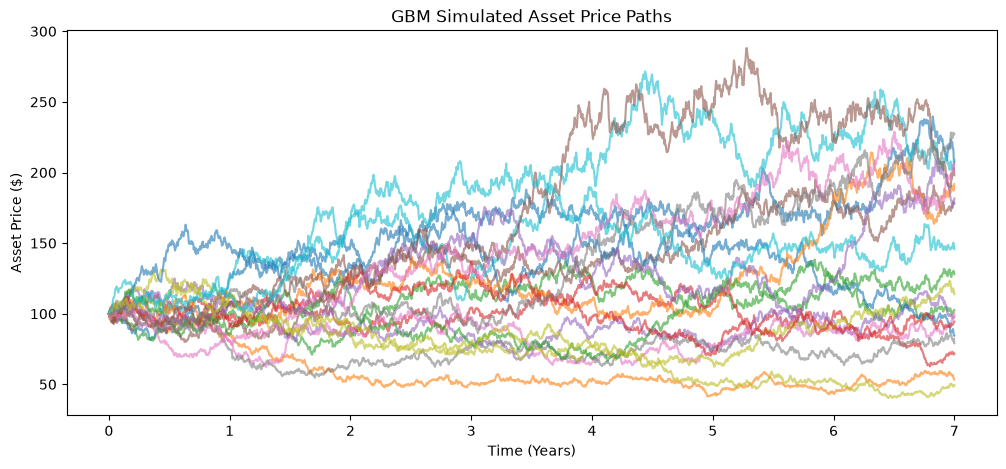

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(times, S, alpha=0.6)


plt.title("GBM Simulated Asset Price Paths")
plt.xlabel("Time (Years)")
plt.ylabel("Asset Price ($)")
plt.show()

## Validation
Validates model against theoretical mean and standard deviation as well as log return distribution

New simulation instance

In [10]:
I_val = 10000 # greater sample size
S_val, times = gbm_simulate(S0, mu, sigma, T, N, I_val)

Theretical values vs simualted values

In [11]:
mean_th = S0 * np.exp(mu * T)
var_th  = S0**2 * np.exp(2 * mu * T) * (np.exp(sigma**2 * T) - 1)
std_th  = np.sqrt(var_th)

mean_sim = S_val[-1].mean()
std_sim  = S_val[-1].std()

print(f"{'':15} {'Theoretical':>12} {'Simulated':>12}")
print(f"{'Mean':15} {mean_th:>12.4f} {mean_sim:>12.4f}")
print(f"{'Std Dev':15} {std_th:>12.4f} {std_sim:>12.4f}")
print(f"\nMean  error : {abs(mean_th - mean_sim):.4f}")
print(f"Std   error : {abs(std_th  - std_sim):.4f}")

                 Theoretical    Simulated
Mean                141.9068     142.1976
Std Dev              80.6662      79.6951

Mean  error : 0.2909
Std   error : 0.9711


Plots histogram of simulated data agaisnt theoretical normal distribution

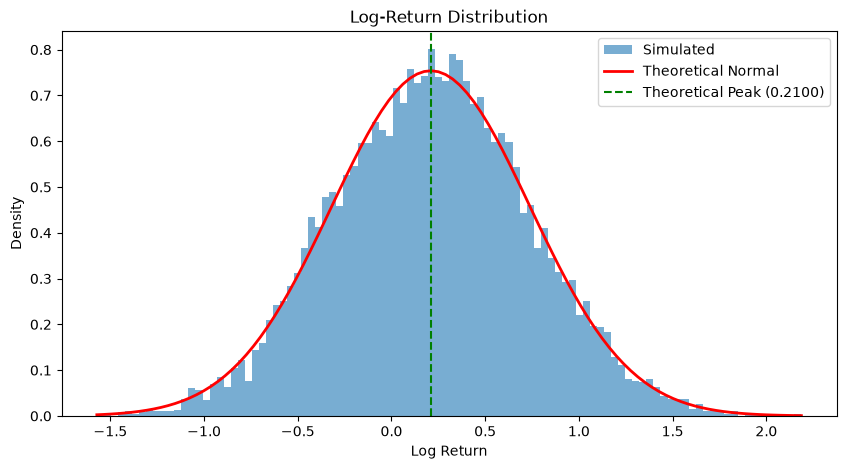

In [12]:
log_returns = np.log(S_val[-1] / S0)

log_mean_th   = (mu - 0.5 * sigma**2) * T # theoretcal mean of log-return distribution
log_std_sim = sigma * np.sqrt(T) # theoretcal meanstandard deviation of log-return distribution


plt.figure(figsize=(10, 5))

x = np.linspace(log_returns.min(), log_returns.max(), 100)

plt.hist(log_returns, bins=100, density=True, alpha=0.6, label='Simulated') # histogram of simulated data in 100 bins
plt.plot(x, stats.norm.pdf(x, log_mean_th, log_std_sim),
         'r-', lw=2, label='Theoretical Normal') # theoretical log-return distribution

plt.axvline(log_mean_th, color='green', linestyle='--', lw=1.5, 
            label=f'Theoretical Peak ({log_mean_th:.4f})') # vertical line at theoretical peak of log-return distribution


plt.title("Log-Return Distribution")
plt.xlabel("Log Return")
plt.ylabel("Density")
plt.legend()